In [2]:
import numpy as np
import torch
import torch.nn as nn

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
from scipy.special import expit

#### Load Test Data from `.npz`

Assuming your `.npz` file contains multiple arrays, you can load them as follows. If it only contains one array, you might directly access `data['array_name']` or `data[list(data.keys())[0]]`.

In [4]:

loaded_data = np.load('test_dataset_v0.npz')
print(f"Arrays found in npz file: {list(loaded_data.keys())}")

if len(loaded_data.keys()) > 0:
    first_key = list(loaded_data.keys())[0]
    print(f"First array '{first_key}' shape: {loaded_data[first_key].shape}")
else:
    print("No arrays found in the .npz file.")

Arrays found in npz file: ['song_id', 'time', 'valence', 'arousal', 'valence_std', 'arousal_std']
First array 'song_id' shape: (22756,)


#### Load Pre-trained LSTM Model from `.pth`

To load your PyTorch LSTM model, you first need to define the exact class structure of your model. The `state_dict` will then be loaded into an instance of this class. Please adjust the `LSTMModel` definition to match your original model's architecture (input size, hidden size, number of layers, etc.).

In [5]:
import torch.nn as nn

class ImprovedLSTMModel(nn.Module):

    def __init__(self, n_mels: int = 128, hidden_size: int = 256,
                 num_layers: int = 3, dropout: float = 0.4):
        super().__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=n_mels,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )

        self.attn_q = nn.Linear(hidden_size * 2, hidden_size)
        self.attn_k = nn.Linear(hidden_size * 2, hidden_size)
        self.attn_v = nn.Linear(hidden_size * 2, hidden_size)
        self.scale  = hidden_size ** 0.5

        # Klasyfikator
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 2),
            nn.Tanh()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # BiLSTM oczekuje (batch, seq_len, features)
        x = x.transpose(1, 2)                          # → (B, n_frames, n_mels)
        lstm_out, _ = self.lstm(x)                     # → (B, n_frames, H*2)

        # Scaled dot-product attention
        Q = self.attn_q(lstm_out)                      # (B, T, H)
        K = self.attn_k(lstm_out)
        V = self.attn_v(lstm_out)

        scores  = torch.matmul(Q, K.transpose(1, 2)) / self.scale
        weights = torch.softmax(scores, dim=-1)
        context = torch.matmul(weights, V).mean(dim=1) # (B, H)

        return self.classifier(context)                # (B, 2), tanh output

n_mels = 128
hidden_size = 128
num_layers = 3
dropout = 0.3

model = ImprovedLSTMModel(n_mels=n_mels, hidden_size=hidden_size, num_layers=num_layers, dropout=dropout)

try:
    checkpoint = torch.load('lstm_hs128_l3_d0.3_lr5e-04_best.pth')
    model.load_state_dict(checkpoint['model_state'])
    model.eval()
    print("LSTM model loaded successfully and set to evaluation mode.")
except Exception as e:
    print(f"An error occurred while loading the model: {e}")

LSTM model loaded successfully and set to evaluation mode.


In [6]:
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pickle

# Define the MelSpectrogramDataset class as provided in your original script
class MelSpectrogramDataset(Dataset):
    def __init__(self, mel_specs, valences, arousals):
        self.mel_specs = mel_specs  # List of numpy arrays/tensors
        self.valences = torch.tensor(valences, dtype=torch.float32)
        self.arousals = torch.tensor(arousals, dtype=torch.float32)

    def __len__(self):
        return len(self.mel_specs)

    def __getitem__(self, idx):
        # Convert mel_spec to tensor if it's not already
        mel_spec_tensor = torch.tensor(self.mel_specs[idx], dtype=torch.float32)
        return {
            'mel_spec': mel_spec_tensor,
            'valence': self.valences[idx],
            'arousal': self.arousals[idx]
        }

### Evaluation on Test Data

Now we will prepare the test data for evaluation, make predictions with the loaded model, and calculate the evaluation metrics.

In [14]:
# Load test mel spectrograms
try:
    with open('test_mel_specs_v0.pkl', 'rb') as f:
        test_mel_specs = pickle.load(f)
    print(f"Loaded test_mel_specs.pkl with {len(test_mel_specs)} samples.")
except FileNotFoundError:
    print("Error: 'test_mel_specs.pkl' not found. Please ensure it's uploaded.")
    test_mel_specs = [] # Initialize as empty to prevent further errors
except Exception as e:
    print(f"An error occurred while loading test_mel_specs.pkl: {e}")

# Ensure loaded_data is available from the previous cell
if 'loaded_data' in locals() and len(test_mel_specs) > 0:
    # Assuming 'valence' and 'arousal' keys exist in loaded_data
    try:
        test_valences = loaded_data['valence']
        test_arousals = loaded_data['arousal']

        test_dataset = MelSpectrogramDataset(
            test_mel_specs,
            test_valences,
            test_arousals
        )

        # Create a DataLoader for the test set
        batch_size = 32 # You can adjust this batch size
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
        print(f"Test DataLoader created with {len(test_loader)} batches.")

        # Set device
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model.to(device)
        model.eval() # Ensure model is in evaluation mode

        all_pred = []
        all_target = []

        with torch.no_grad():
            for batch in test_loader:
                mel_specs = batch['mel_spec'].to(device)
                valences = batch['valence'].to(device)
                arousals = batch['arousal'].to(device)

                predictions = model(mel_specs)

                all_pred.append(predictions.cpu().numpy())
                all_target.append(torch.stack([valences, arousals], dim=1).cpu().numpy())

        all_pred = np.vstack(all_pred)
        all_target = np.vstack(all_target)

        # Compute and print metrics
        metrics = {
            'valence_mae': mean_absolute_error(all_target[:, 0], all_pred[:, 0]),
            'arousal_mae': mean_absolute_error(all_target[:, 1], all_pred[:, 1]),
            'valence_rmse': np.sqrt(mean_squared_error(all_target[:, 0], all_pred[:, 0])),
            'arousal_rmse': np.sqrt(mean_squared_error(all_target[:, 1], all_pred[:, 1])),
            'valence_corr': np.corrcoef(all_target[:, 0], all_pred[:, 0])[0, 1] if all_target.shape[0] > 1 else np.nan,
            'arousal_corr': np.corrcoef(all_target[:, 1], all_pred[:, 1])[0, 1] if all_target.shape[0] > 1 else np.nan,
        }

        print(f"\nTest Metrics:")
        print(f"  Valence: MAE={metrics['valence_mae']:.4f}, "
              f"RMSE={metrics['valence_rmse']:.4f}, "
              f"Corr={metrics['valence_corr']:.4f}")
        print(f"  Arousal: MAE={metrics['arousal_mae']:.4f}, "
              f"RMSE={metrics['arousal_rmse']:.4f}, "
              f"Corr={metrics['arousal_corr']:.4f}")

    except KeyError as ke:
        print(f"Error: Missing key in loaded_data: {ke}. Ensure 'valence' and 'arousal' are present.")
    except Exception as e:
        print(f"An error occurred during evaluation: {e}")
else:
    print("Skipping evaluation: test_mel_specs or loaded_data not available.")

Loaded test_mel_specs.pkl with 22756 samples.
Test DataLoader created with 712 batches.

Test Metrics:
  Valence: MAE=0.1571, RMSE=0.1998, Corr=0.4200
  Arousal: MAE=0.2009, RMSE=0.2549, Corr=0.6173


### Visualizing Example Mel Spectrograms

Let's visualize a couple of mel spectrograms from the test dataset to get a better understanding of the input data the model receives.

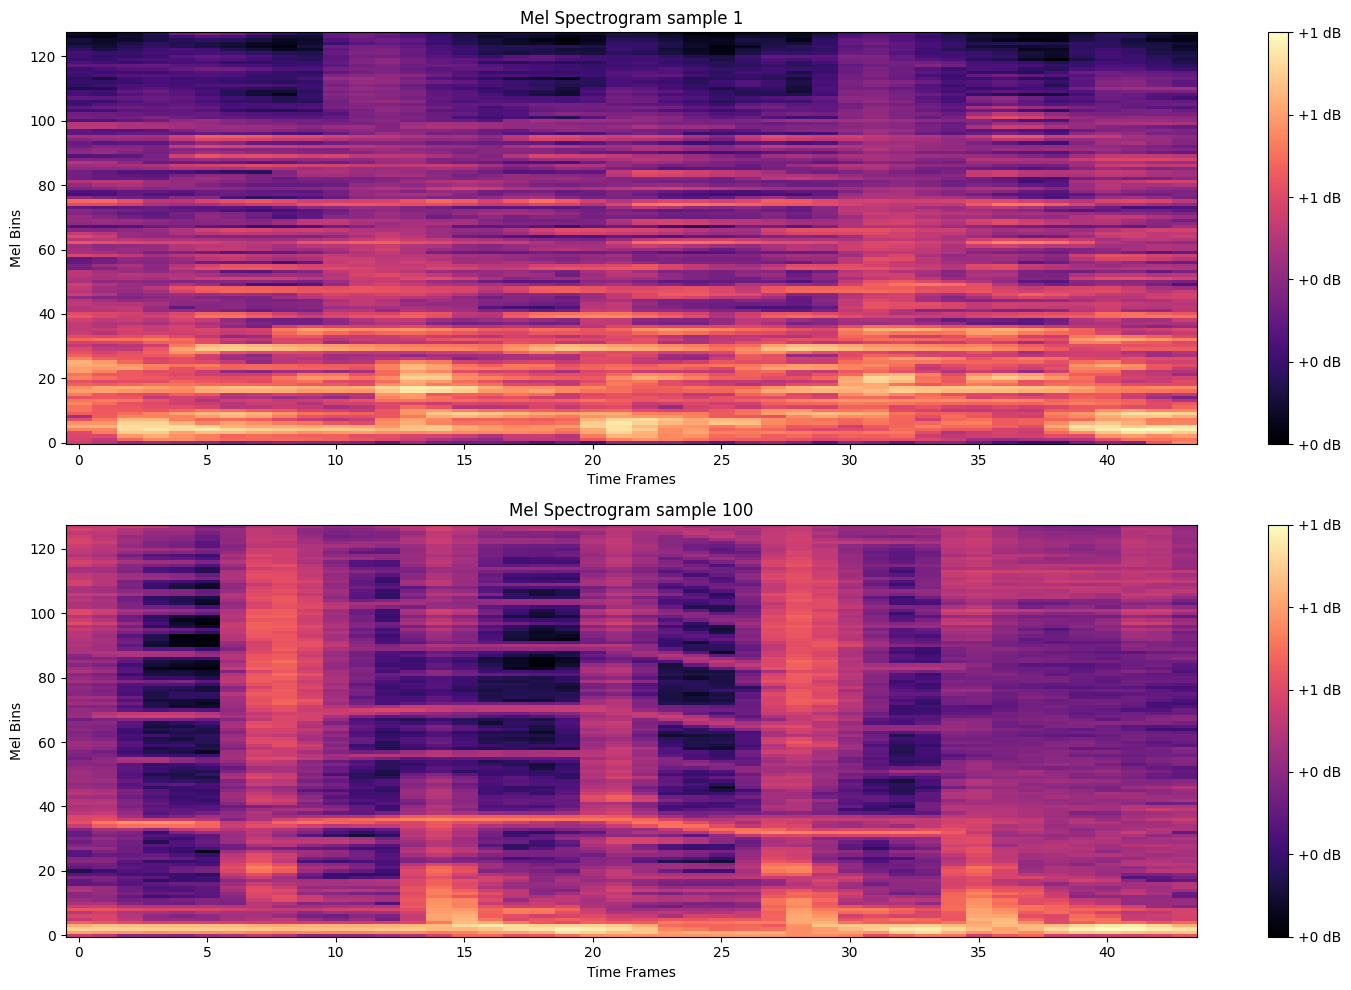

In [15]:
import matplotlib.pyplot as plt

# Check if test_mel_specs is available and not empty
if 'test_mel_specs' in locals() and len(test_mel_specs) > 1:
    # Select the first two mel spectrograms
    mel_spec_1 = test_mel_specs[0]
    mel_spec_2 = test_mel_specs[100]

    fig, axes = plt.subplots(2, 1, figsize=(15, 10))

    # Plot first mel spectrogram
    im1 = axes[0].imshow(mel_spec_1, origin='lower', aspect='auto', cmap='magma')
    axes[0].set_title('Mel Spectrogram sample 1')
    axes[0].set_xlabel('Time Frames')
    axes[0].set_ylabel('Mel Bins')
    fig.colorbar(im1, ax=axes[0], format='%+2.0f dB')

    # Plot second mel spectrogram
    im2 = axes[1].imshow(mel_spec_2, origin='lower', aspect='auto', cmap='magma')
    axes[1].set_title('Mel Spectrogram sample 100')
    axes[1].set_xlabel('Time Frames')
    axes[1].set_ylabel('Mel Bins')
    fig.colorbar(im2, ax=axes[1], format='%+2.0f dB')

    plt.tight_layout()
    plt.show()
else:
    print("Cannot visualize mel spectrograms: 'test_mel_specs' not available or contains too few samples.")

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from typing import Tuple, List, Dict
import json

class EmotionTagger:

    def __init__(self, thresholds=None):
        if thresholds is None:
            # Simplified thresholds, as valence/arousal now use 0 as the division line
            thresholds = {
                'neutral_radius': 0.1 # Using the value from XUDRSho1rDqy which seems reasonable for a neutral zone.
            }
        self.thresholds = thresholds

        # 5 emotions (4 quadranty + neutral)
        self.emotion_labels = ['NEUTRAL', 'HAPPY', 'CALM', 'ANGRY', 'SAD']

        # Mapping dla każdej emocji
        self.emotion_colors = {
            'NEUTRAL': '#808080',  # Gray
            'HAPPY': '#FFD700',    # Gold
            'CALM': '#87CEEB',     # Sky blue
            'ANGRY': '#FF6347',    # Tomato red
            'SAD': '#4169E1'       # Royal blue
        }

    def tag_emotion(self, valence: float, arousal: float) -> str:
        neutral_r = self.thresholds['neutral_radius']

        # Neutral zone around (0,0)
        dist = np.sqrt(valence**2 + arousal**2)
        if dist < neutral_r:
            return 'NEUTRAL'

        # Quadrant classification using raw valence and arousal
        if valence >= 0 and arousal >= 0:
            return 'HAPPY'        # Positive + Active
        elif valence >= 0 and arousal < 0:
            return 'CALM'         # Positive + Passive
        elif valence < 0 and arousal >= 0:
            return 'ANGRY'        # Negative + Active
        else: # valence < 0 and arousal < 0
            return 'SAD'          # Negative + Passive

    def tag_batch(self, valences: np.ndarray, arousals: np.ndarray) -> np.ndarray:
        emotions = np.array([
            self.tag_emotion(v, a)
            for v, a in zip(valences, arousals)
        ])
        return emotions

    def emotion_to_label_id(self, emotion: str) -> int:
        """Convert emotion string → numeric ID."""
        return self.emotion_labels.index(emotion)

    def label_id_to_emotion(self, label_id: int) -> str:
        """Convert numeric ID → emotion string."""
        return self.emotion_labels[label_id]

class EmotionEvaluator:

    def __init__(self, tagger: EmotionTagger = None):
        self.tagger = tagger if tagger else EmotionTagger()

    def evaluate(self,
                 true_valences: np.ndarray,
                 true_arousals: np.ndarray,
                 pred_valences: np.ndarray,
                 pred_arousals: np.ndarray) -> Dict:

        # Tag emotions
        true_emotions = self.tagger.tag_batch(true_valences, true_arousals)
        pred_emotions = self.tagger.tag_batch(pred_valences, pred_arousals)

        # Convert to numeric IDs dla metryk
        true_ids = np.array([self.tagger.emotion_to_label_id(e) for e in true_emotions])
        pred_ids = np.array([self.tagger.emotion_to_label_id(e) for e in pred_emotions])

        # Metrics
        accuracy = accuracy_score(true_ids, pred_ids)

        # Per-emotion accuracy
        per_emotion_acc = {}
        for emotion in self.tagger.emotion_labels:
            emotion_mask = true_emotions == emotion
            if emotion_mask.sum() > 0:
                emotion_acc = accuracy_score(
                    true_ids[emotion_mask],
                    pred_ids[emotion_mask]
                )
                per_emotion_acc[emotion] = emotion_acc

        # Confusion matrix
        cm = confusion_matrix(true_ids, pred_ids,
                             labels=range(len(self.tagger.emotion_labels)))

        # Classification report
        class_report = classification_report(
            true_ids, pred_ids,
            target_names=self.tagger.emotion_labels,
            labels=range(len(self.tagger.emotion_labels)), # <--- ADDED THIS LINE
            output_dict=True,
            zero_division=0
        )

        # Distribution stats
        dist_true = {
            emotion: (true_emotions == emotion).sum()
            for emotion in self.tagger.emotion_labels
        }
        dist_pred = {
            emotion: (pred_emotions == emotion).sum()
            for emotion in self.tagger.emotion_labels
        }

        results = {
            'overall_accuracy': float(accuracy),
            'per_emotion_accuracy': {k: float(v) for k, v in per_emotion_acc.items()},
            'confusion_matrix': cm.tolist(),
            'classification_report': class_report,
            'true_distribution': dist_true,
            'pred_distribution': dist_pred,
            'true_emotions': true_emotions.tolist(),
            'pred_emotions': pred_emotions.tolist(),
            'true_ids': true_ids.tolist(),
            'pred_ids': pred_ids.tolist()
        }

        return results

    def plot_confusion_matrix(self, results: Dict, save_path='emotion_confusion_matrix.png'):
        """Plot confusion matrix."""
        cm = np.array(results['confusion_matrix'])

        fig, ax = plt.subplots(figsize=(10, 8))

        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=self.tagger.emotion_labels,
            yticklabels=self.tagger.emotion_labels,
            ax=ax,
            cbar_kws={'label': 'Count'}
        )

        ax.set_xlabel('Predicted Emotion')
        ax.set_ylabel('True Emotion')
        ax.set_title(f"Emotion Classification Confusion Matrix\n"
                    f"Accuracy: {results['overall_accuracy']:.1%}")

        plt.tight_layout()
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✓ Saved confusion matrix: {save_path}")
        plt.close()

    def plot_distributions(self, results: Dict, save_path='emotion_distributions.png'):
        """Plot true vs predicted emotion distributions."""
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        emotions = self.tagger.emotion_labels
        true_counts = [results['true_distribution'][e] for e in emotions]
        pred_counts = [results['pred_distribution'][e] for e in emotions]

        x = np.arange(len(emotions))
        width = 0.35

        # True distribution
        axes[0].bar(x - width/2, true_counts, width, label='True', alpha=0.8)
        axes[0].bar(x + width/2, pred_counts, width, label='Predicted', alpha=0.8)
        axes[0].set_xlabel('Emotion')
        axes[0].set_ylabel('Count')
        axes[0].set_title('True vs Predicted Emotion Distribution')
        axes[0].set_xticks(x)
        axes[0].set_xticklabels(emotions)
        axes[0].legend()
        axes[0].grid(alpha=0.3)

        # Per-emotion accuracy
        per_emotion_acc = results['per_emotion_accuracy']
        accs = [per_emotion_acc.get(e, 0) for e in emotions]
        colors = [self.tagger.emotion_colors.get(e, '#808080') for e in emotions]

        axes[1].bar(emotions, accs, color=colors, alpha=0.7)
        axes[1].set_ylabel('Accuracy')
        axes[1].set_title('Per-Emotion Classification Accuracy')
        axes[1].set_ylim([0, 1])
        axes[1].grid(alpha=0.3, axis='y')

        # Add percentage labels on bars
        for i, (emotion, acc) in enumerate(zip(emotions, accs)):
            axes[1].text(i, acc + 0.02, f'{acc:.0%}', ha='center', va='bottom')

        plt.tight_layout()
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✓ Saved distributions: {save_path}")
        plt.close()

    def plot_valence_arousal_scatter(self,
                                     true_valences: np.ndarray,
                                     true_arousals: np.ndarray,
                                     pred_valences: np.ndarray,
                                     pred_arousals: np.ndarray,
                                     save_path='emotion_scatter.png'):

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        # True emotions scatter
        ax = axes[0]
        true_emotions = self.tagger.tag_batch(true_valences, true_arousals)

        for emotion in self.tagger.emotion_labels:
            mask = true_emotions == emotion
            ax.scatter(
                true_valences[mask],
                true_arousals[mask],
                label=emotion,
                color=self.tagger.emotion_colors[emotion],
                alpha=0.6,
                s=50,
                edgecolors='black',
                linewidth=0.5
            )

        # Linie podziału dla zakresu [-1,1]
        ax.axvline(x=0.0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
        ax.axhline(y=0.0, color='gray', linestyle='--', alpha=0.5, linewidth=1)

        # Neutral zone wokół środka (0,0)
        from matplotlib.patches import Circle
        neutral_r = self.tagger.thresholds['neutral_radius']
        circle = Circle((0.0, 0.0), neutral_r, fill=False,
                        linestyle='--', color='gray', alpha=0.5)
        ax.add_patch(circle)

        ax.set_xlabel('Valence')
        ax.set_ylabel('Arousal')
        ax.set_title('True Emotions (Valence-Arousal Space)')
        ax.set_xlim([-1.05, 1.05])
        ax.set_ylim([-1.05, 1.05])
        ax.legend()
        ax.grid(alpha=0.3)

        # Predicted emotions scatter
        ax = axes[1]
        pred_emotions = self.tagger.tag_batch(pred_valences, pred_arousals)

        for emotion in self.tagger.emotion_labels:
            mask = pred_emotions == emotion
            ax.scatter(
                pred_valences[mask],
                pred_arousals[mask],
                label=emotion,
                color=self.tagger.emotion_colors[emotion],
                alpha=0.6,
                s=50,
                edgecolors='black',
                linewidth=0.5
            )

        # Linie podziału dla zakresu [-1,1]
        ax.axvline(x=0.0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
        ax.axhline(y=0.0, color='gray', linestyle='--', alpha=0.5, linewidth=1)

        # Neutral zone wokół środka (0,0)
        circle = Circle((0.0, 0.0), neutral_r, fill=False,
                        linestyle='--', color='gray', alpha=0.5)
        ax.add_patch(circle)

        ax.set_xlabel('Valence')
        ax.set_ylabel('Arousal')
        ax.set_title('Predicted Emotions (Valence-Arousal Space)')
        ax.set_xlim([-1.05, 1.05])
        ax.set_ylim([-1.05, 1.05])
        ax.legend()
        ax.grid(alpha=0.3)

        plt.tight_layout()
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✓ Saved scatter plot: {save_path}")
        plt.close()

In [51]:
import numpy as np
import pickle
import torch
# The EmotionTagger and EmotionEvaluator classes are defined in cell AxHAfkYDJ6sJ, so no need to import them from a file.
import json

def evaluate_lstm_emotions(
    model,
    test_mel_specs,
    true_valences,
    true_arousals,
    output_file='lstm_emotion_results.json'
):
    """
    Ewaluuje klasyfikację emocji na zbiorze testowym za pomocą modelu LSTM.

    Args:
        model: Załadowany model LSTM (ImprovedLSTMModel).
        test_mel_specs: Lista mel spektrogramów dla danych testowych.
        true_valences: Rzeczywiste wartości walencji dla danych testowych.
        true_arousals: Rzeczywiste wartości wzbudzenia dla danych testowych.
        output_file: Plik, do którego mają zostać zapisane wyniki.
    """

    print("="*70)
    print("LSTM EMOTION CLASSIFICATION EVALUATION")
    print("="*70 + "\n")

    print(f"✓ Loaded {len(true_valences)} test samples\n")

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device) # Ensure model is on the correct device
    model.eval() # Set model to evaluation mode

    print("Making predictions...")
    pred_valences = []
    pred_arousals = []

    with torch.no_grad():
        for i, mel_spec in enumerate(test_mel_specs):
            if (i + 1) % 5000 == 0:
                print(f"  {i + 1}/{len(test_mel_specs)}")

            # Prepare input
            x = torch.FloatTensor(mel_spec).unsqueeze(0).to(device)
            # x shape: (1, n_mels, n_frames)

            # Predict
            output = model(x)
            # output shape: (1, 2)

            pred_valences.append(output[0, 0].cpu().numpy())
            pred_arousals.append(output[0, 1].cpu().numpy())

    pred_valences = np.array(pred_valences)
    pred_arousals = np.array(pred_arousals)

    # The model output with Tanh activation is already in (-1, 1), so no further scaling is needed.
    # pred_valences = expit(pred_valences)  # Sigmoid: (-∞, +∞) → (0, 1)
    # pred_valences = np.clip(pred_valences, 0, 1)

    # pred_arousals = expit(pred_arousals)  # Sigmoid: (-∞, +∞) → (0, 1)
    # pred_arousals = np.clip(pred_arousals, 0, 1)

    print(f"✓ Predictions made\n")

    # Evaluate emotions
    print("Evaluating emotion classification...")
    tagger = EmotionTagger()
    evaluator = EmotionEvaluator(tagger)

    results = evaluator.evaluate(true_valences, true_arousals,
                                  pred_valences, pred_arousals)

    print(f"\n{'='*70}")
    print("RESULTS")
    print(f"{'='*70}\n")

    print(f"✓ Overall Emotion Classification Accuracy: {results['overall_accuracy']:.1%}\n")

    print("Per-Emotion Accuracy:")
    for emotion in tagger.emotion_labels:
        acc = results['per_emotion_accuracy'].get(emotion, 0)
        count = results['true_distribution'][emotion]
        print(f"  {emotion:10s}: {acc:6.1%} (n={count:5d})")

    print("\nTrue Emotion Distribution:")
    for emotion in tagger.emotion_labels:
        count = results['true_distribution'][emotion]
        pct = count / len(true_valences) * 100
        print(f"  {emotion:10s}: {count:5d} ({pct:5.1f}%)")

    print("\nPredicted Emotion Distribution:")
    for emotion in tagger.emotion_labels:
        count = results['pred_distribution'][emotion]
        pct = count / len(pred_valences) * 100
        print(f"  {emotion:10s}: {count:5d} ({pct:5.1f}%)")

    # Regression metrics (valence & arousal separately)
    from sklearn.metrics import mean_absolute_error, mean_squared_error

    print(f"\n{'='*70}")
    print("REGRESSION METRICS (Valence & Arousal)")
    print(f"{'='*70}\n")

    mae_val = mean_absolute_error(true_valences, pred_valences)
    mae_arou = mean_absolute_error(true_arousals, pred_arousals)
    rmse_val = np.sqrt(mean_squared_error(true_valences, pred_valences))
    rmse_arou = np.sqrt(mean_squared_error(true_arousals, pred_arousals))

    print(f"Valence:")
    print(f"  MAE:  {mae_val:.4f}")
    print(f"  RMSE: {rmse_val:.4f}")

    print(f"\nArousal:")
    print(f"  MAE:  {mae_arou:.4f}")
    print(f"  RMSE: {rmse_arou:.4f}")

    # Save results
    print(f"\n{'='*70}")
    print("SAVING RESULTS")
    print(f"{'='*70}\n")

    full_results = {
        **results,
        'regression_metrics': {
            'valence_mae': float(mae_val),
            'valence_rmse': float(rmse_val),
            'arousal_mae': float(mae_arou),
            'arousal_rmse': float(rmse_arou)
        }
    }

    # with open(output_file, 'w') as f:
    #     json.dump(full_results, f, indent=2)

    # print(f"✓ Saved results to: {output_file}")

    # Plot results (assuming evaluator methods are available)
    evaluator.plot_confusion_matrix(results, 'emotion_cm_lstm.png')
    evaluator.plot_distributions(results, 'emotion_dist_lstm.png')
    evaluator.plot_valence_arousal_scatter(
        true_valences, true_arousals,
        pred_valences, pred_arousals,
        'emotion_scatter_lstm.png'
    )

    print("\n✓ All plots saved!")

    return results

def compare_models(models_to_test):
    # This function is not used in the current context but kept for completeness
    # if it were to be used for comparing multiple models. It would also need refactoring
    # to accept pre-loaded data/models if it were to be called directly.
    print("\n\n" + "="*70)
    print("COMPARING MULTIPLE MODELS")
    print("="*70 + "\n")

    comparison_results = {}

    for model_name, (model_obj, mel_specs, valences, arousals) in models_to_test.items():
        print(f"\nEvaluating: {model_name}")

        try:
            results = evaluate_lstm_emotions(
                model=model_obj,
                test_mel_specs=mel_specs,
                true_valences=valences,
                true_arousals=arousals,
                output_file=f'{model_name}_emotion_results.json'
            )

            comparison_results[model_name] = {
                'overall_accuracy': results['overall_accuracy'],
                'per_emotion_accuracy': results['per_emotion_accuracy']
            }
        except Exception as e:
            print(f"✗ Error: {e}")
            comparison_results[model_name] = {'error': str(e)}

    # Print comparison table
    print("\n\n" + "="*70)
    print("MODEL COMPARISON")
    print("="*70 + "\n")

    print(f"{'Model':<30} {'Overall Acc':>15}")
    print("-" * 47)

    for model_name, res in comparison_results.items():
        if 'error' not in res:
            acc = res['overall_accuracy']
            print(f"{model_name:<30} {acc:>14.1%}")
        else:
            print(f"{model_name:<30} {'ERROR':>15}")

In [52]:
results = evaluate_lstm_emotions(
    model=model,
    test_mel_specs=test_mel_specs,
    true_valences=test_valences,
    true_arousals=test_arousals,
    output_file='lstm_emotion_results.json'
)

LSTM EMOTION CLASSIFICATION EVALUATION

✓ Loaded 22756 test samples

Making predictions...
  5000/22756
  10000/22756
  15000/22756
  20000/22756
✓ Predictions made

Evaluating emotion classification...

RESULTS

✓ Overall Emotion Classification Accuracy: 44.3%

Per-Emotion Accuracy:
  NEUTRAL   :  12.2% (n= 1554)
  HAPPY     :  58.7% (n= 5958)
  CALM      :  47.7% (n= 6683)
  ANGRY     :  22.6% (n= 2842)
  SAD       :  45.0% (n= 5719)

True Emotion Distribution:
  NEUTRAL   :  1554 (  6.8%)
  HAPPY     :  5958 ( 26.2%)
  CALM      :  6683 ( 29.4%)
  ANGRY     :  2842 ( 12.5%)
  SAD       :  5719 ( 25.1%)

Predicted Emotion Distribution:
  NEUTRAL   :  2131 (  9.4%)
  HAPPY     :  6446 ( 28.3%)
  CALM      :  6930 ( 30.5%)
  ANGRY     :  2196 (  9.7%)
  SAD       :  5053 ( 22.2%)

REGRESSION METRICS (Valence & Arousal)

Valence:
  MAE:  0.1571
  RMSE: 0.1998

Arousal:
  MAE:  0.2009
  RMSE: 0.2549

SAVING RESULTS

✓ Saved confusion matrix: emotion_cm_lstm.png
✓ Saved distributions: emo

Displaying Emotion Classification Confusion Matrix:


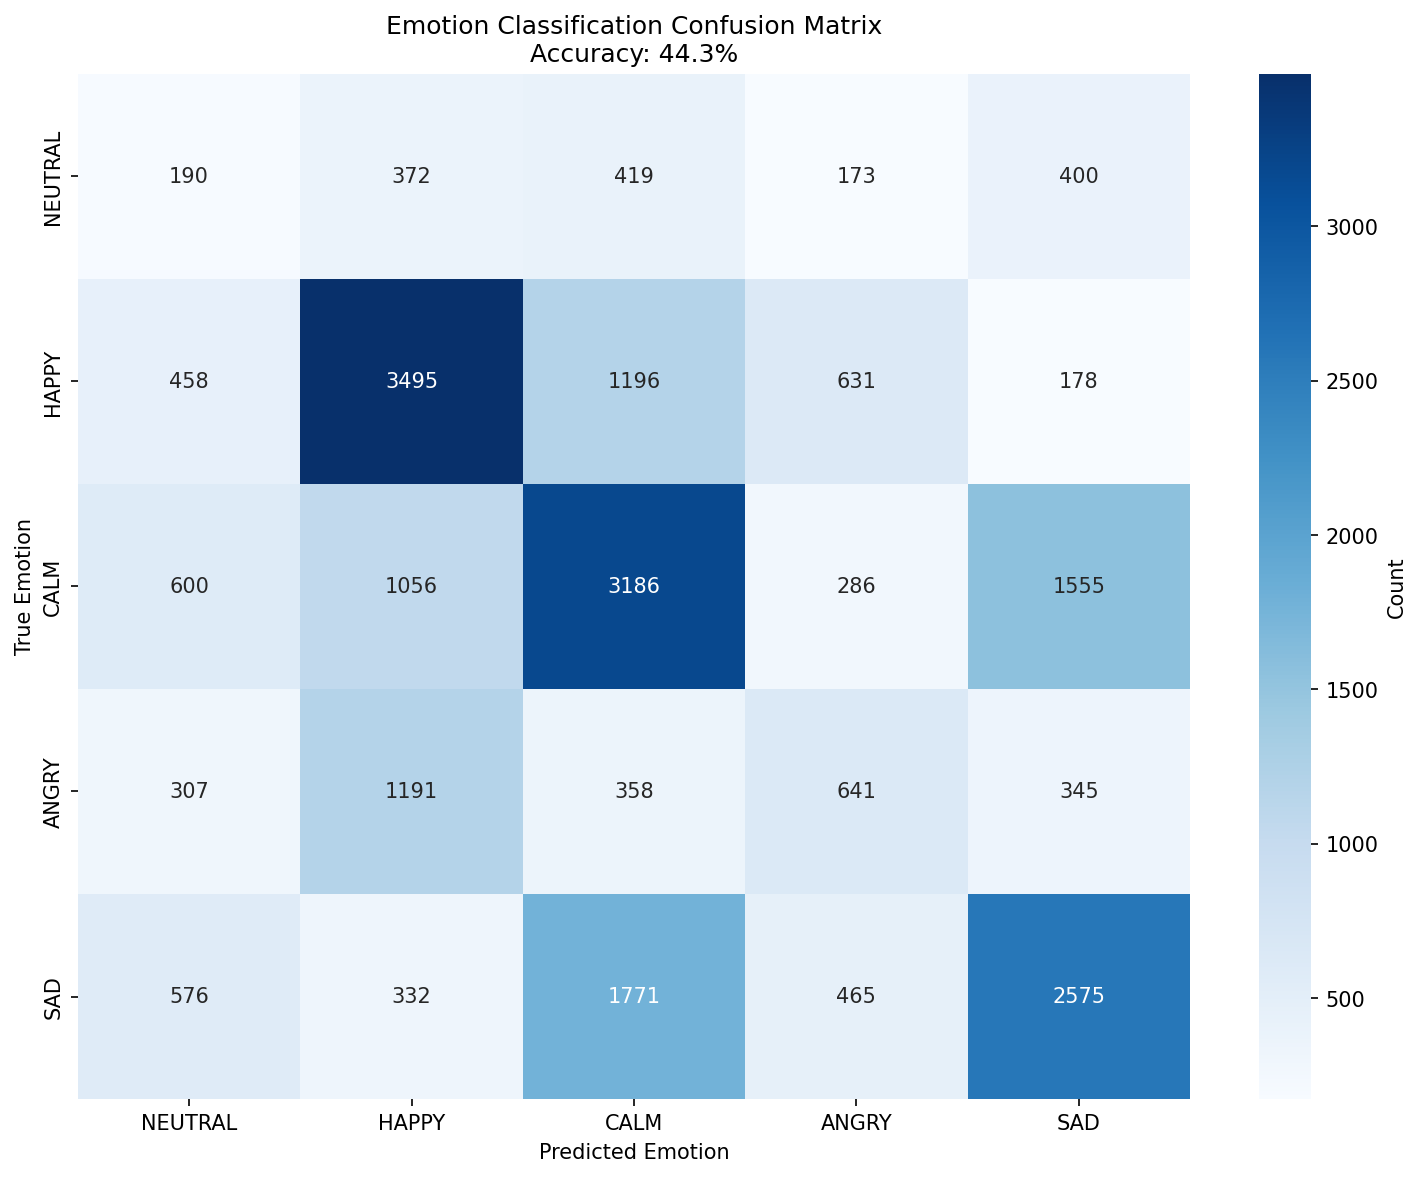

In [56]:
from IPython.display import Image, display

print("Displaying Emotion Classification Confusion Matrix:")
display(Image(filename='emotion_cm_lstm.png'))


Displaying True vs Predicted Emotion Distributions:


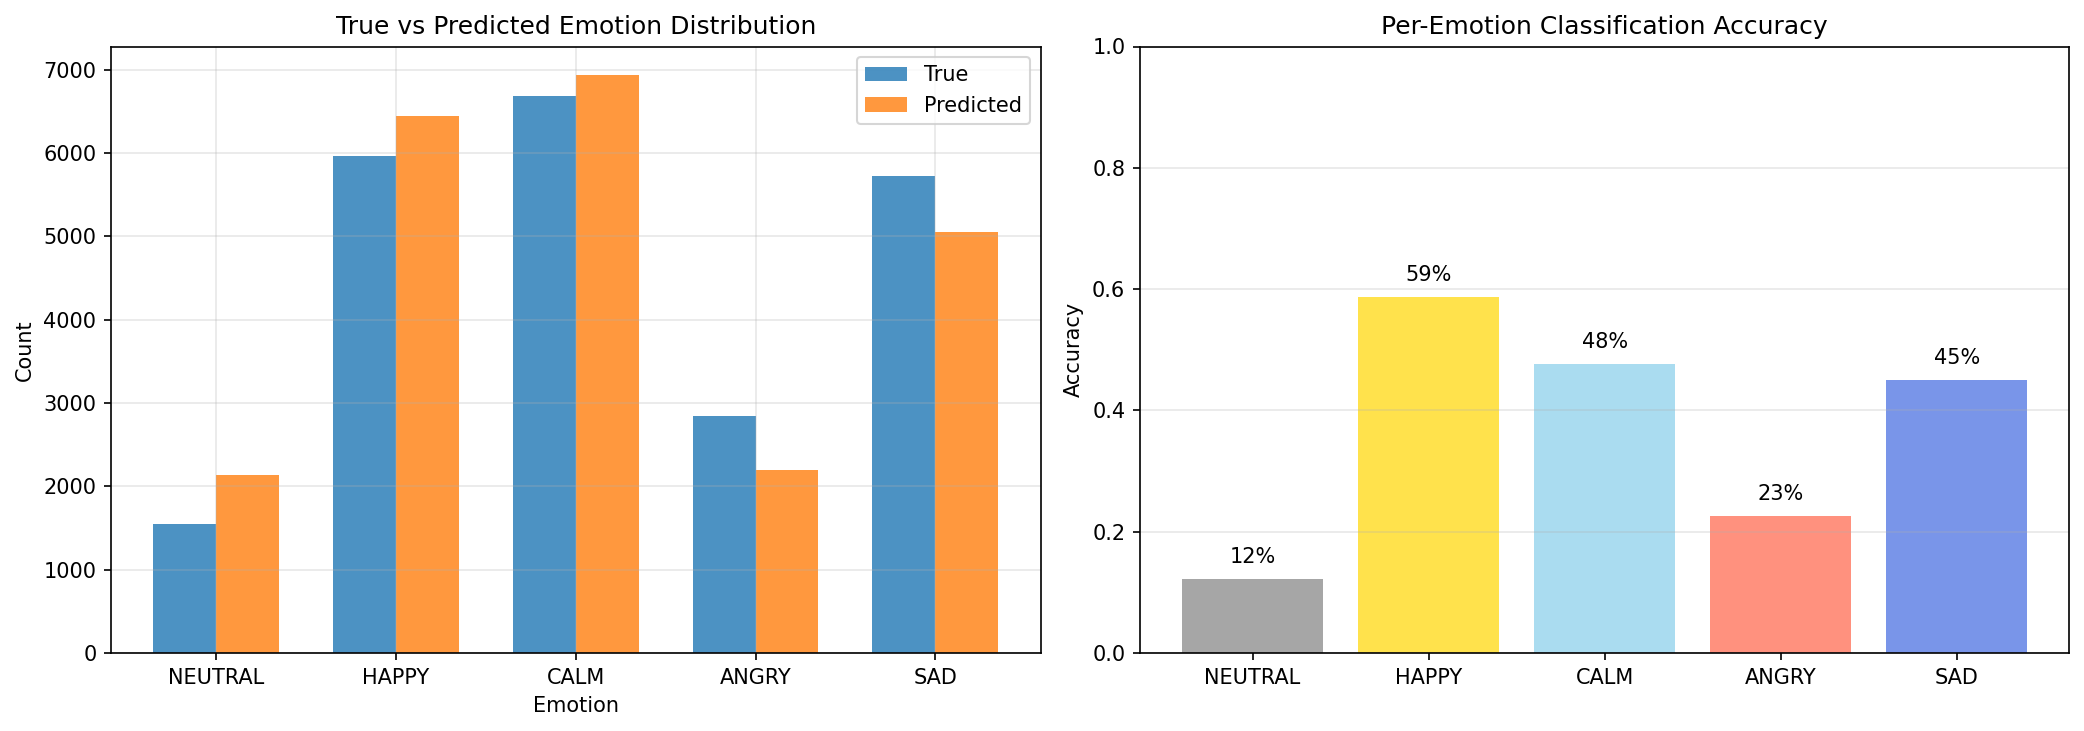

In [54]:

print("\nDisplaying True vs Predicted Emotion Distributions:")
display(Image(filename='emotion_dist_lstm.png'))



Displaying Valence-Arousal Scatter Plot:


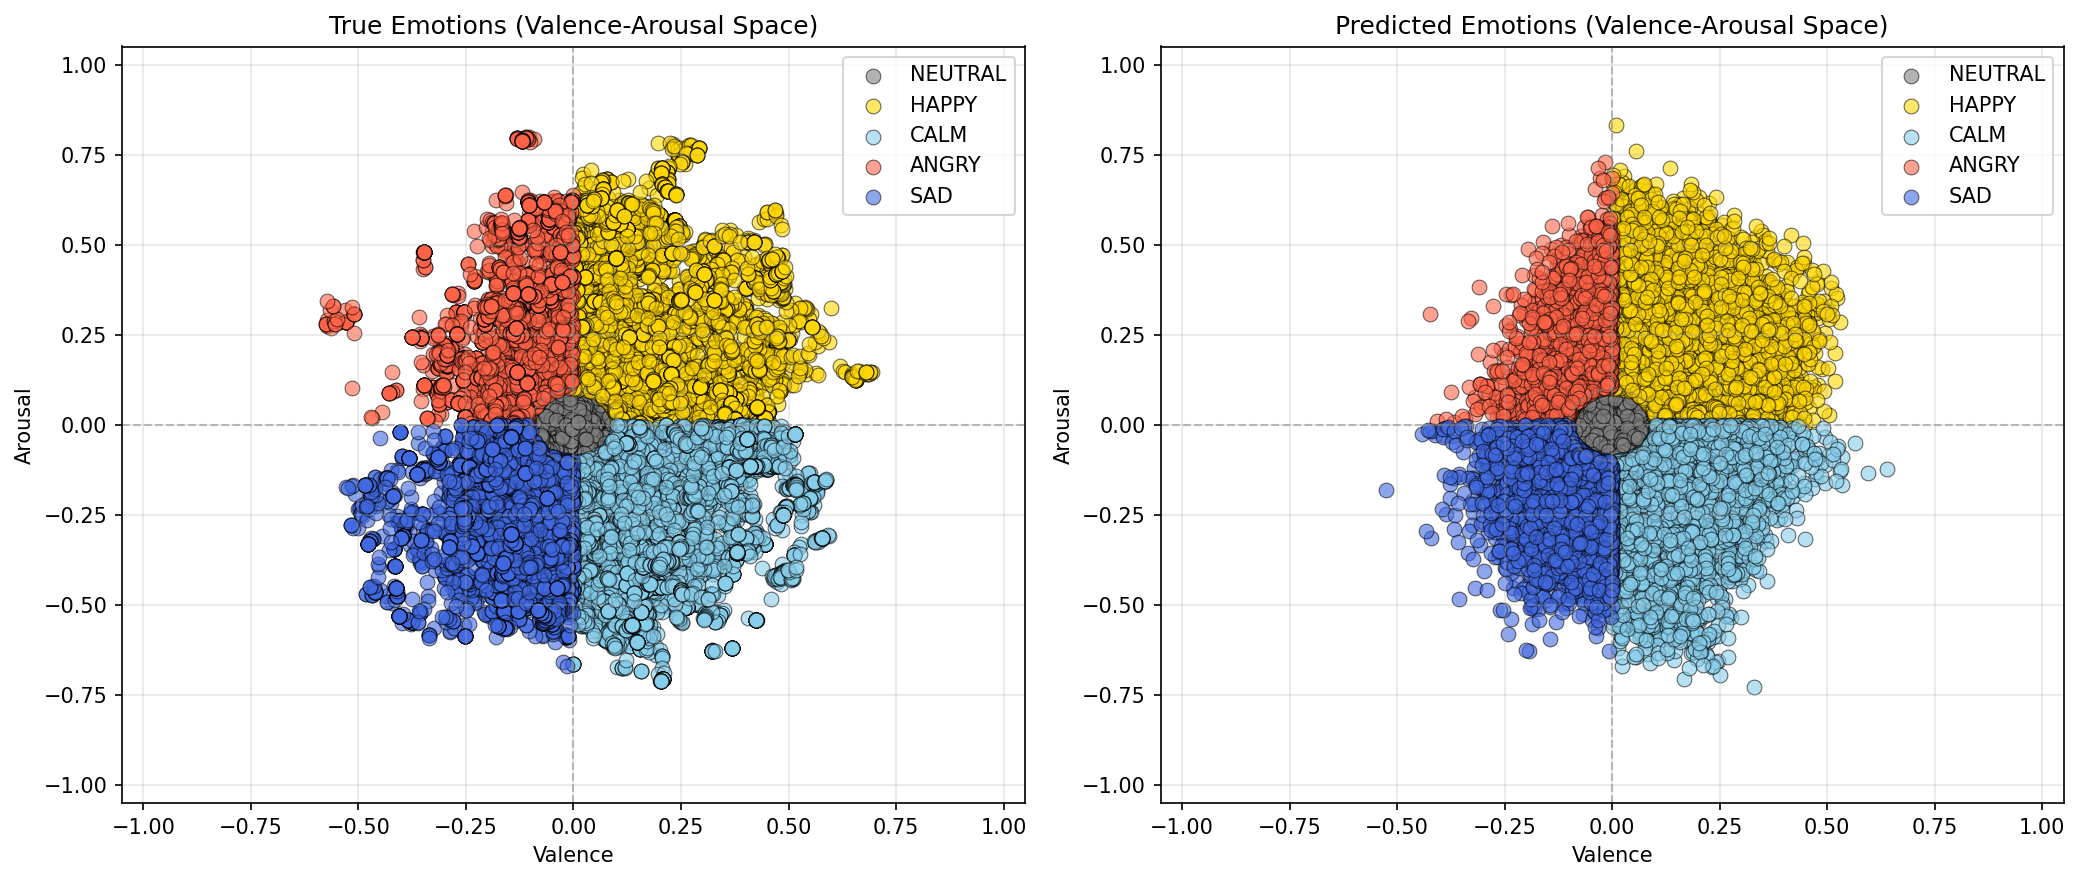

In [55]:

print("\nDisplaying Valence-Arousal Scatter Plot:")
display(Image(filename='emotion_scatter_lstm.png'))